# MS4 Algorithm 027A Analysis

Main voice algorithm used by 52 of 66 MS4 programs.
Includes piano, strings, brass, woodwinds, and most other instruments.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from sam8905_interpreter import (
    SAM8905Interpreter,
    plot_waveform,
    export_wav,
    print_state,
)
from sam8905_aram_decoder import decode_algorithm, analyze_dram_usage
from ms4_programs import ALGORITHMS, PROGRAMS_027A

import importlib
import sam8905_interpreter
importlib.reload(sam8905_interpreter)

import ms4_programs
importlib.reload(ms4_programs)

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 4)

## Algorithm Decode

Disassemble the A-RAM instructions and analyze D-RAM usage.

In [2]:
# Load algorithm
aram_027a = ALGORITHMS['027A']

# Decode and display
print(decode_algorithm(aram_027a))

# D-RAM usage analysis
print("\nD-RAM Usage:")
usage = analyze_dram_usage(aram_027a)
for addr, counts in sorted(usage.items()):
    print(f"  D[{addr:2d}]: read={counts['read']}, write={counts['write']}")


PC00: 08EF  RM 1, <WPHI>
PC01: 7EFB  RSP, <clearB>
PC02: 50BD  RM 10, <WB, WWF>
PC03: 28F7  RM 5, <WXY>
PC04: 78FD  RM 15, <WWF>
PC05: 4CCF  RP 9, <WM, WPHI>
PC06: 59F7  RM 11, <WXY, WSP> ***
PC07: 11EF  RM 2, <WPHI, WSP> ***
PC08: 20FD  RM 4, <WWF>
PC09: 086F  RM 1, <WA, WPHI>
PC10: 3ADF  RADD 7, <WM>
PC11: 113F  RM 2, <WA, WB, WSP> ***
PC12: 42DF  RADD 8, <WM>
PC13: 18BF  RM 3, <WB>
PC14: 7CF7  RP, <WXY>
PC15: 43DF  RADD 8, <WM, WSP> ***
PC16: 30BF  RM 6, <WB>
PC17: 2876  RM 5, <WA, WXY, WACC>
PC18: 41EF  RM 8, <WPHI, WSP> ***
PC19: 20FD  RM 4, <WWF>
PC20: 38EE  RM 7, <WPHI, WACC>
PC21: 2BDF  RADD 5, <WM, WSP> ***
PC22: 087F  RM 1, <WA>
PC23: 00BF  RM 0, <WB>
PC24: 0ADF  RADD 1, <WM>
PC25: 48F7  RM 9, <WXY>
PC26: 113F  RM 2, <WA, WB, WSP> ***
PC27: 12DF  RADD 2, <WM>
PC28: 18BF  RM 3, <WB>
PC29: 13DE  RADD 2, <WM, WACC, WSP> ***
PC30: 7FFF  RSP, <WSP> ***
PC31: 7FFF  RSP, <WSP> ***

D-RAM Usage:
  D[ 0]: read=1, write=0
  D[ 1]: read=3, write=1
  D[ 2]: read=3, write=2
  D[ 3]: read

## Available Programs

List all programs using this algorithm.

In [3]:
print(f"Programs using algorithm 027A ({len(PROGRAMS_027A)} total):\n")
for i, prog in enumerate(PROGRAMS_027A):
    print(f"{i:2d}. [{prog['idx']:2d}] {prog['name']:<12} slots={prog['slot_count']} "
          f"dram0=0x{prog['dram_entry0']['word']:04X}")

Programs using algorithm 027A (52 total):

 0. [ 0] dpiano27     slots=1 dram0=0xA401
 1. [ 1] dstringh     slots=1 dram0=0xD401
 2. [ 2] dcoros7      slots=1 dram0=0x9401
 3. [ 3] dsaxs6       slots=1 dram0=0xB401
 4. [ 4] dtrumph      slots=1 dram0=0x0401
 5. [ 5] dpfluteh     slots=1 dram0=0x3401
 6. [ 6] dbvios10     slots=1 dram0=0x0401
 7. [ 7] dclaguih     slots=1 dram0=0x6401
 8. [ 8] dvibesh      slots=1 dram0=0xE401
 9. [ 9] djorgh       slots=1 dram0=0x9401
10. [10] dchorg1h     slots=1 dram0=0xC401
11. [11] dmtrumph     slots=1 dram0=0xF401
12. [12] dbrassh      slots=1 dram0=0x2401
13. [15] dmand4       slots=1 dram0=0x6401
14. [16] dsaxa4       slots=1 dram0=0xB401
15. [17] drsax4       slots=1 dram0=0xE401
16. [20] dharmh       slots=1 dram0=0x7401
17. [21] dleadgh      slots=1 dram0=0xA401
18. [22] dfzguith     slots=1 dram0=0xD401
19. [23] dfhamh       slots=1 dram0=0x0401
20. [24] dclikorh     slots=1 dram0=0x3401
21. [25] drockorh     slots=1 dram0=0x6401
22. [27] df

## Program Selection and D-RAM Setup

Select a program and set up initial D-RAM configuration.

In [4]:
# Select program by index in PROGRAMS_027A list (0-51)
PROGRAM_INDEX = 9  # Change this to select different program

prog = PROGRAMS_027A[PROGRAM_INDEX]
print(f"Selected: {prog['name']} (MS4 program #{prog['idx']})")
print(f"  Flags: 0x{prog['flags']:02X}, Slots: {prog['slot_count']}")
print(f"  D-RAM entry0: word=0x{prog['dram_entry0']['word']:04X}, "
      f"addr_nibble={prog['dram_entry0']['addr_nibble']}, "
      f"mix_bits={prog['dram_entry0']['mix_bits']}")

# Voice slot data (envelope/modulation config)
if prog['voice_slots']:
    print(f"\n  Voice slots ({len(prog['voice_slots'])}):\n")
    for i, slot in enumerate(prog['voice_slots']):
        data_hex = ' '.join(f'{b:02X}' for b in slot['data'])
        print(f"    Slot {i}: ptr=0x{slot['ptr']:04X} data=[{data_hex}]")
        # Decode voice init data
        d = slot['data']
        env_ptr = d[0] | (d[1] << 8)
        ctrl = d[2]
        print(f"            env_tbl=0x{env_ptr:04X}, ctrl=0x{ctrl:02X}, "
              f"atk=0x{d[4]:02X}, depth=0x{d[5]:02X}, rate=0x{d[6]:02X}")

# D-RAM stream (raw parameter data)
if prog['dram_stream']:
    stream_hex = ' '.join(f'{b:02X}' for b in prog['dram_stream'][:32])
    print(f"\n  D-RAM stream ({len(prog['dram_stream'])} bytes): {stream_hex}...")

Selected: djorgh (MS4 program #9)
  Flags: 0x11, Slots: 1
  D-RAM entry0: word=0x9401, addr_nibble=3, mix_bits=1

  Voice slots (1):

    Slot 0: ptr=0x0BC0 data=[E4 06 40 00 00 00 00]
            env_tbl=0x06E4, ctrl=0x40, atk=0x00, depth=0x00, rate=0x00

  D-RAM stream (14 bytes): 08 00 E8 C0 00 00 00 00 00 00 00 00 00 80...


## D-RAM Configuration

Each program exports its initial D-RAM configuration via `dram_init` (16 x 19-bit words).

The exported data includes:
- **Waveform words**: Set to internal sine (0x20000) at algorithm-specific indices
- **Amplitude words**: Set from stream handlers where available
- **Phase increment** (D[0]): Left at 0 - needs runtime calculation from MIDI note

For testing, we override:
- **D[0]**: Phase increment for test frequency
- **D[2], D[5], D[11]**: Amplitude/mix values (until envelope modulators are implemented)

### Algorithm 027A D-RAM Layout

| Word | Function | Notes |
|------|----------|-------|
| 0 | Phase increment | Added to D[1] each sample |
| 1 | Phase accumulator | Updated each sample |
| 2 | Osc1 amplitude + mix | bus[18:7]=amp, [5:3]=mixL, [2:0]=mixR |
| 4 | Waveform select | WWF target (internal sine = 0x100) |
| 5 | Osc2 amplitude | Read twice, written once |
| 10 | Waveform bank | WWF at PC02 |
| 11 | Amplitude 2 + mix | WSP sets mix from this word |
| 15 | Waveform/control | WWF at PC04, also ALG[10:8], IDLE[11] |

In [5]:
# Create interpreter and load algorithm
sam = SAM8905Interpreter()
sam.load_aram(aram_027a, offset=0)  # Load as algorithm 0

# Load program's initial D-RAM configuration
dram_slot0 = prog['dram_init'].copy()

# Override test parameters (until envelope is implemented)
TEST_FREQ = 440  # Hz
TEST_AMP = 0x07FF  # Max amplitude
MIX_L, MIX_R = 7, 7  # Full pan

# Calculate phase increment for test frequency
phase_inc = int(4096 * TEST_FREQ / 44100)

# Set phase increment (D[0]) - needed for oscillation
dram_slot0[0] = phase_inc << 7

# Override amplitude in amplitude words (until envelope modulators are implemented)
# amp_params tells us which word has the amplitude from the stream
# but for simple test, set D[2], D[5], D[11] to known good values
amp_value = (TEST_AMP << 7) | (MIX_L << 3) | MIX_R
if dram_slot0[2] == 0:
    dram_slot0[2] = amp_value
if dram_slot0[5] == 0:
    dram_slot0[5] = amp_value
if dram_slot0[11] == 0:
    dram_slot0[11] = amp_value

sam.load_dram(0, dram_slot0)

print(f"Loaded {prog['name']} D-RAM configuration:")
print(f"  Phase increment: {phase_inc} (0x{phase_inc:03X}) for {TEST_FREQ}Hz")
print(f"  Test amplitude: 0x{TEST_AMP:03X}, Mix: L={MIX_L}, R={MIX_R}")
print(f"\nProgram parameters:")
print(f"  pitch_params: {prog['pitch_params']}")
print(f"  amp_params: {prog['amp_params']}")
print(f"  waveform_words: {prog['waveform_words']}")
print(f"\nD-RAM init (non-zero):")
for i, v in enumerate(dram_slot0):
    if v != 0:
        print(f"  D[{i:2d}] = 0x{v:05X}")

Loaded djorgh D-RAM configuration:
  Phase increment: 40 (0x028) for 440Hz
  Test amplitude: 0x7FF, Mix: L=7, R=7

Program parameters:
  pitch_params: {'note_offset': 232, 'fine_tune': 0, 'vel_sens': 0}
  amp_params: {'level': 0, 'amp': 127, 'vel_sens': 0, 'env_ctrl': 0}
  waveform_words: [4, 10, 15]

D-RAM init (non-zero):
  D[ 0] = 0x01400
  D[ 2] = 0x3FFBF
  D[ 4] = 0x20000
  D[ 5] = 0x3FFBF
  D[10] = 0x20000
  D[11] = 0x3FFBF
  D[15] = 0x20000


## Run and Visualize

Generated 2000 samples
L range: [-778, 777]
R range: [-778, 777]


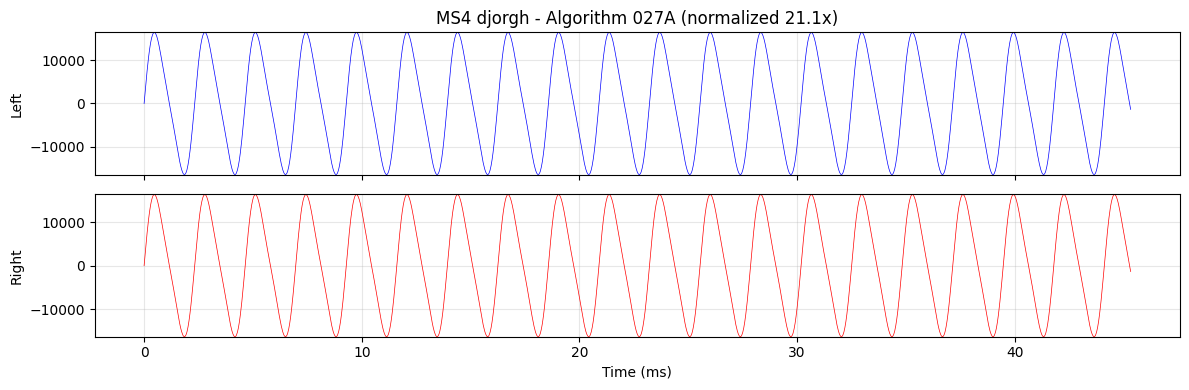

In [6]:
# Generate samples
samples = sam.run(2000, active_slots=[0])

print(f"Generated {len(samples)} samples")
print(f"L range: [{samples[:, 0].min()}, {samples[:, 0].max()}]")
print(f"R range: [{samples[:, 1].min()}, {samples[:, 1].max()}]")

# Plot with normalization for weak signals
plot_waveform(samples, title=f"MS4 {prog['name']} - Algorithm 027A", normalize=True)
plt.show()

## State Inspection

In [6]:
print_state(sam.state, slot=0)

SAM8905 Register State
  A = 0x00000  (+0)
  B = 0x00000  (+0)
  X = 0x000  (+0)
  Y = 0x000  (+0)
  PHI = 0x000  (0)
  WF = 0x000
  MUL = 0x00000  (+0)

  CARRY = False
  CLEAR_RQST = False
  INT_MOD = False

  MIX_L = 0  MIX_R = 0
  L_ACC = +0  R_ACC = +0

D-RAM Slot 0:
  D[ 0] = 0x00000  (+0)
  D[ 1] = 0x01400  (+5120)
  D[ 2] = 0x3FFBF  (+262079)
  D[ 3] = 0x00000  (+0)
  D[ 4] = 0x20000  (+131072)
  D[ 5] = 0x3FFBF  (+262079)
  D[ 6] = 0x00000  (+0)
  D[ 7] = 0x00000  (+0)
  D[ 8] = 0x00000  (+0)
  D[ 9] = 0x00000  (+0)
  D[10] = 0x00000  (+0)
  D[11] = 0x3FFBF  (+262079)
  D[12] = 0x00000  (+0)
  D[13] = 0x00000  (+0)
  D[14] = 0x00000  (+0)
  D[15] = 0x00000  (+0)


## Instruction Trace

Enable tracing to see instruction-by-instruction execution.

In [10]:
# Reset and enable tracing
sam.reset()
sam.load_aram(aram_027a, offset=0)
sam.load_dram(0, dram_slot0)

sam.trace_enabled = True
sam.trace_output = []

# Run just 2 frames to see instruction flow
samples = sam.run(2, active_slots=[0])

print("Instruction trace (2 frames):")
for line in sam.trace_output:
    print(line)

Instruction trace (2 frames):
S00 PC00: 08EF  RM 1, <WPHI>  -> phi=0x00028
S00 PC01: 7EFB  RSP, <clearB>  -> b=0x00000
S00 PC02: 50BD  RM 10, <WB, WWF>  -> b=0x00000, wf=0x00000
S00 PC03: 28F7  RM 5, <WXY>  -> x=0x00000, y=0x007FF, mul=0x00000
S00 PC04: 78FD  RM 15, <WWF>  -> wf=0x00000
S00 PC05: 4CCF  RP 9, <WM, WPHI>  -> phi=0x00000
S00 PC06: 59F7  RM 11, <WXY, WSP>  -> x=0x00000, y=0x007FF, mul=0x00000, mix_l=0x00007, mix_r=0x00007
S00 PC07: 11EF  RM 2, <WPHI, WSP>  -> phi=0x007FF, wf=0x00100
S00 PC08: 20FD  RM 4, <WWF>  -> wf=0x00100
S00 PC09: 086F  RM 1, <WA, WPHI>  -> a=0x01400, phi=0x00028
S00 PC10: 3ADF  RADD 7, <WM>  -> 
S00 PC11: 113F  RM 2, <WA, WB, WSP>  -> a=0x00000, b=0x3FFBF
S00 PC12: 42DF  RADD 8, <WM>  -> 
S00 PC13: 18BF  RM 3, <WB>  -> b=0x00000
S00 PC14: 7CF7  RP, <WXY>  -> x=0x0005B, y=0x00000, mul=0x00000
S00 PC15: 43DF  RADD 8, <WM, WSP>
S00 PC16: 30BF  RM 6, <WB>  -> b=0x00000
S00 PC17: 2876  RM 5, <WA, WXY, WACC>  -> a=0x3FFBF, x=0x0005B, y=0x007FF, mul=0x02D7A,

## Notes

### Algorithm 027A Signal Flow

Based on the decoded instructions:

1. **PC00-05**: Phase setup and waveform selection
   - PHI loaded from D[1]
   - WF set from D[10], D[15]
   
2. **PC06-12**: First oscillator path
   - WXY from D[11], D[2] (amplitude/phase)
   - Filter accumulation via D[7], D[8]

3. **PC13-21**: Second oscillator and mixing
   - Additional WXY operations
   - WACC at PC17, PC20 (two accumulate points)

4. **PC22-29**: Phase update and final output
   - Phase accumulation D[1] += D[0]
   - Final WACC at PC29

### D-RAM Word Assignments (typical)

| Word | Function | Notes |
|------|----------|-------|
| 0 | Phase base | Added to D[1] |
| 1 | Phase accumulator | Updated each sample |
| 2 | Osc1 amplitude + mix | bus[18:7]=amp, [5:3]=mixL, [2:0]=mixR |
| 3 | Filter coeff | Read twice |
| 4 | Waveform select | WWF target |
| 5 | Osc2 amplitude | Read twice, written once |
| 6 | Mix coefficient | Read once |
| 7 | Filter state 1 | |
| 8 | Filter state 2 | |
| 9 | Phase 2 | Secondary oscillator |
| 10 | Waveform bank | |
| 11 | Amplitude 2 | |
| 15 | Control | ALG[10:8], IDLE[11] |